In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Logging
from common.logs import get_stream_and_file_logger
logger = get_stream_and_file_logger(name="AggregateReturns")

for h in logger.handlers:
    print(f"{type(h).__name__} @ level {h.level}")

logger.info("The global logger is now available in the notebook")

2026-06-01 10:23:39,073 AggregateReturns INFO: The global logger is now available in the notebook


RotatingFileHandler @ level 10
StreamHandler @ level 10


In [3]:
import pandas as pd
import seaborn as sns
from pathlib import Path
from matplotlib import pyplot as plt

plt.style.use("default")

from market_impact.utils.data import get_impact_data
from market_impact.impact.lag_one_impact import r1_impact
from common.research.feature_scaling import quantile_bin_data
from market_impact.utils.normalise_impact import r1_mean_impact
from market_impact.impact.aggregate_impact import agg_volume_impact
from wavelets.data_loaders.lobster.get_data import load_data, get_trades
from market_impact.impact.returns import returns, ReturnsDirection, ReturnsType

## 1. Load LOB Data
The data that we study originates from the LOBSTER database, which consists of L3 data listing every market order arrival, limit order arrivals, and cancellation that occurs on the NASDAQ platform during 09:30–16:00 each trading day.

* We load a DataFrame of Trdes and Quotes (TAQ).

In [4]:
tickers = ['TSLA']

# Get paths
current_dir = Path().resolve()
root_dir = current_dir.parents[1]
data_dir = root_dir / "data" / "lobster"

stock_data = {}
for stock in tickers:

    # Load orderbook raw data chosen stock
    filename = f"{stock}_2019_merged.csv"
    stock_file_path = data_dir / stock / filename

    # Read the CSV and store in the dictionary
    stock_data[stock] = load_data(str(stock_file_path))

tsla_l2_lob = stock_data['TSLA']
tsla_l2_lob

,Date,Timestamp,Event,Order_ID,Size,Price,Direction,Ask_Price_1,Ask_Size_1,Bid_Price_1,Bid_Size_1,Ask_Price_2,Ask_Size_2,Bid_Price_2,Bid_Size_2
0,2019-01-02,2019-01-02 09:30:00.083438739,1,11581548,5,305.25,1,306.51,3,306.06,3,306.97,250,305.25,5
1,2019-01-02,2019-01-02 09:30:00.423428343,5,0,308,306.07,1,306.51,3,306.06,3,306.97,250,305.25,5
2,2019-01-02,2019-01-02 09:30:00.423511868,1,11657596,100,306.56,-1,306.51,3,306.06,3,306.56,100,305.25,5
3,2019-01-02,2019-01-02 09:30:00.423526462,1,11657616,100,306.01,1,306.51,3,306.06,3,306.56,100,306.01,100
4,2019-01-02,2019-01-02 09:30:00.424166489,3,11657616,100,306.01,1,306.51,3,306.06,3,306.56,100,305.25,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38721925,2019-12-31,2019-12-31 15:59:59.969709539,1,284532492,1,418.30,-1,418.30,121,418.08,400,418.31,120,418.06,2700
38721926,2019-12-31,2019-12-31 15:59:59.969709539,3,284495100,1,418.31,-1,418.30,120,418.08,400,418.31,120,418.06,2700
38721927,2019-12-31,2019-12-31 15:59:59.993704903,1,284539152,2850,418.30,-1,418.30,2971,418.08,400,418.31,120,418.06,2700
38721928,2019-12-31,2019-12-31 15:59:59.995964989,3,284507860,100,418.08,1,418.30,2971,418.08,300,418.31,120,418.06,2700


Text(0.5, 0, 'Time')

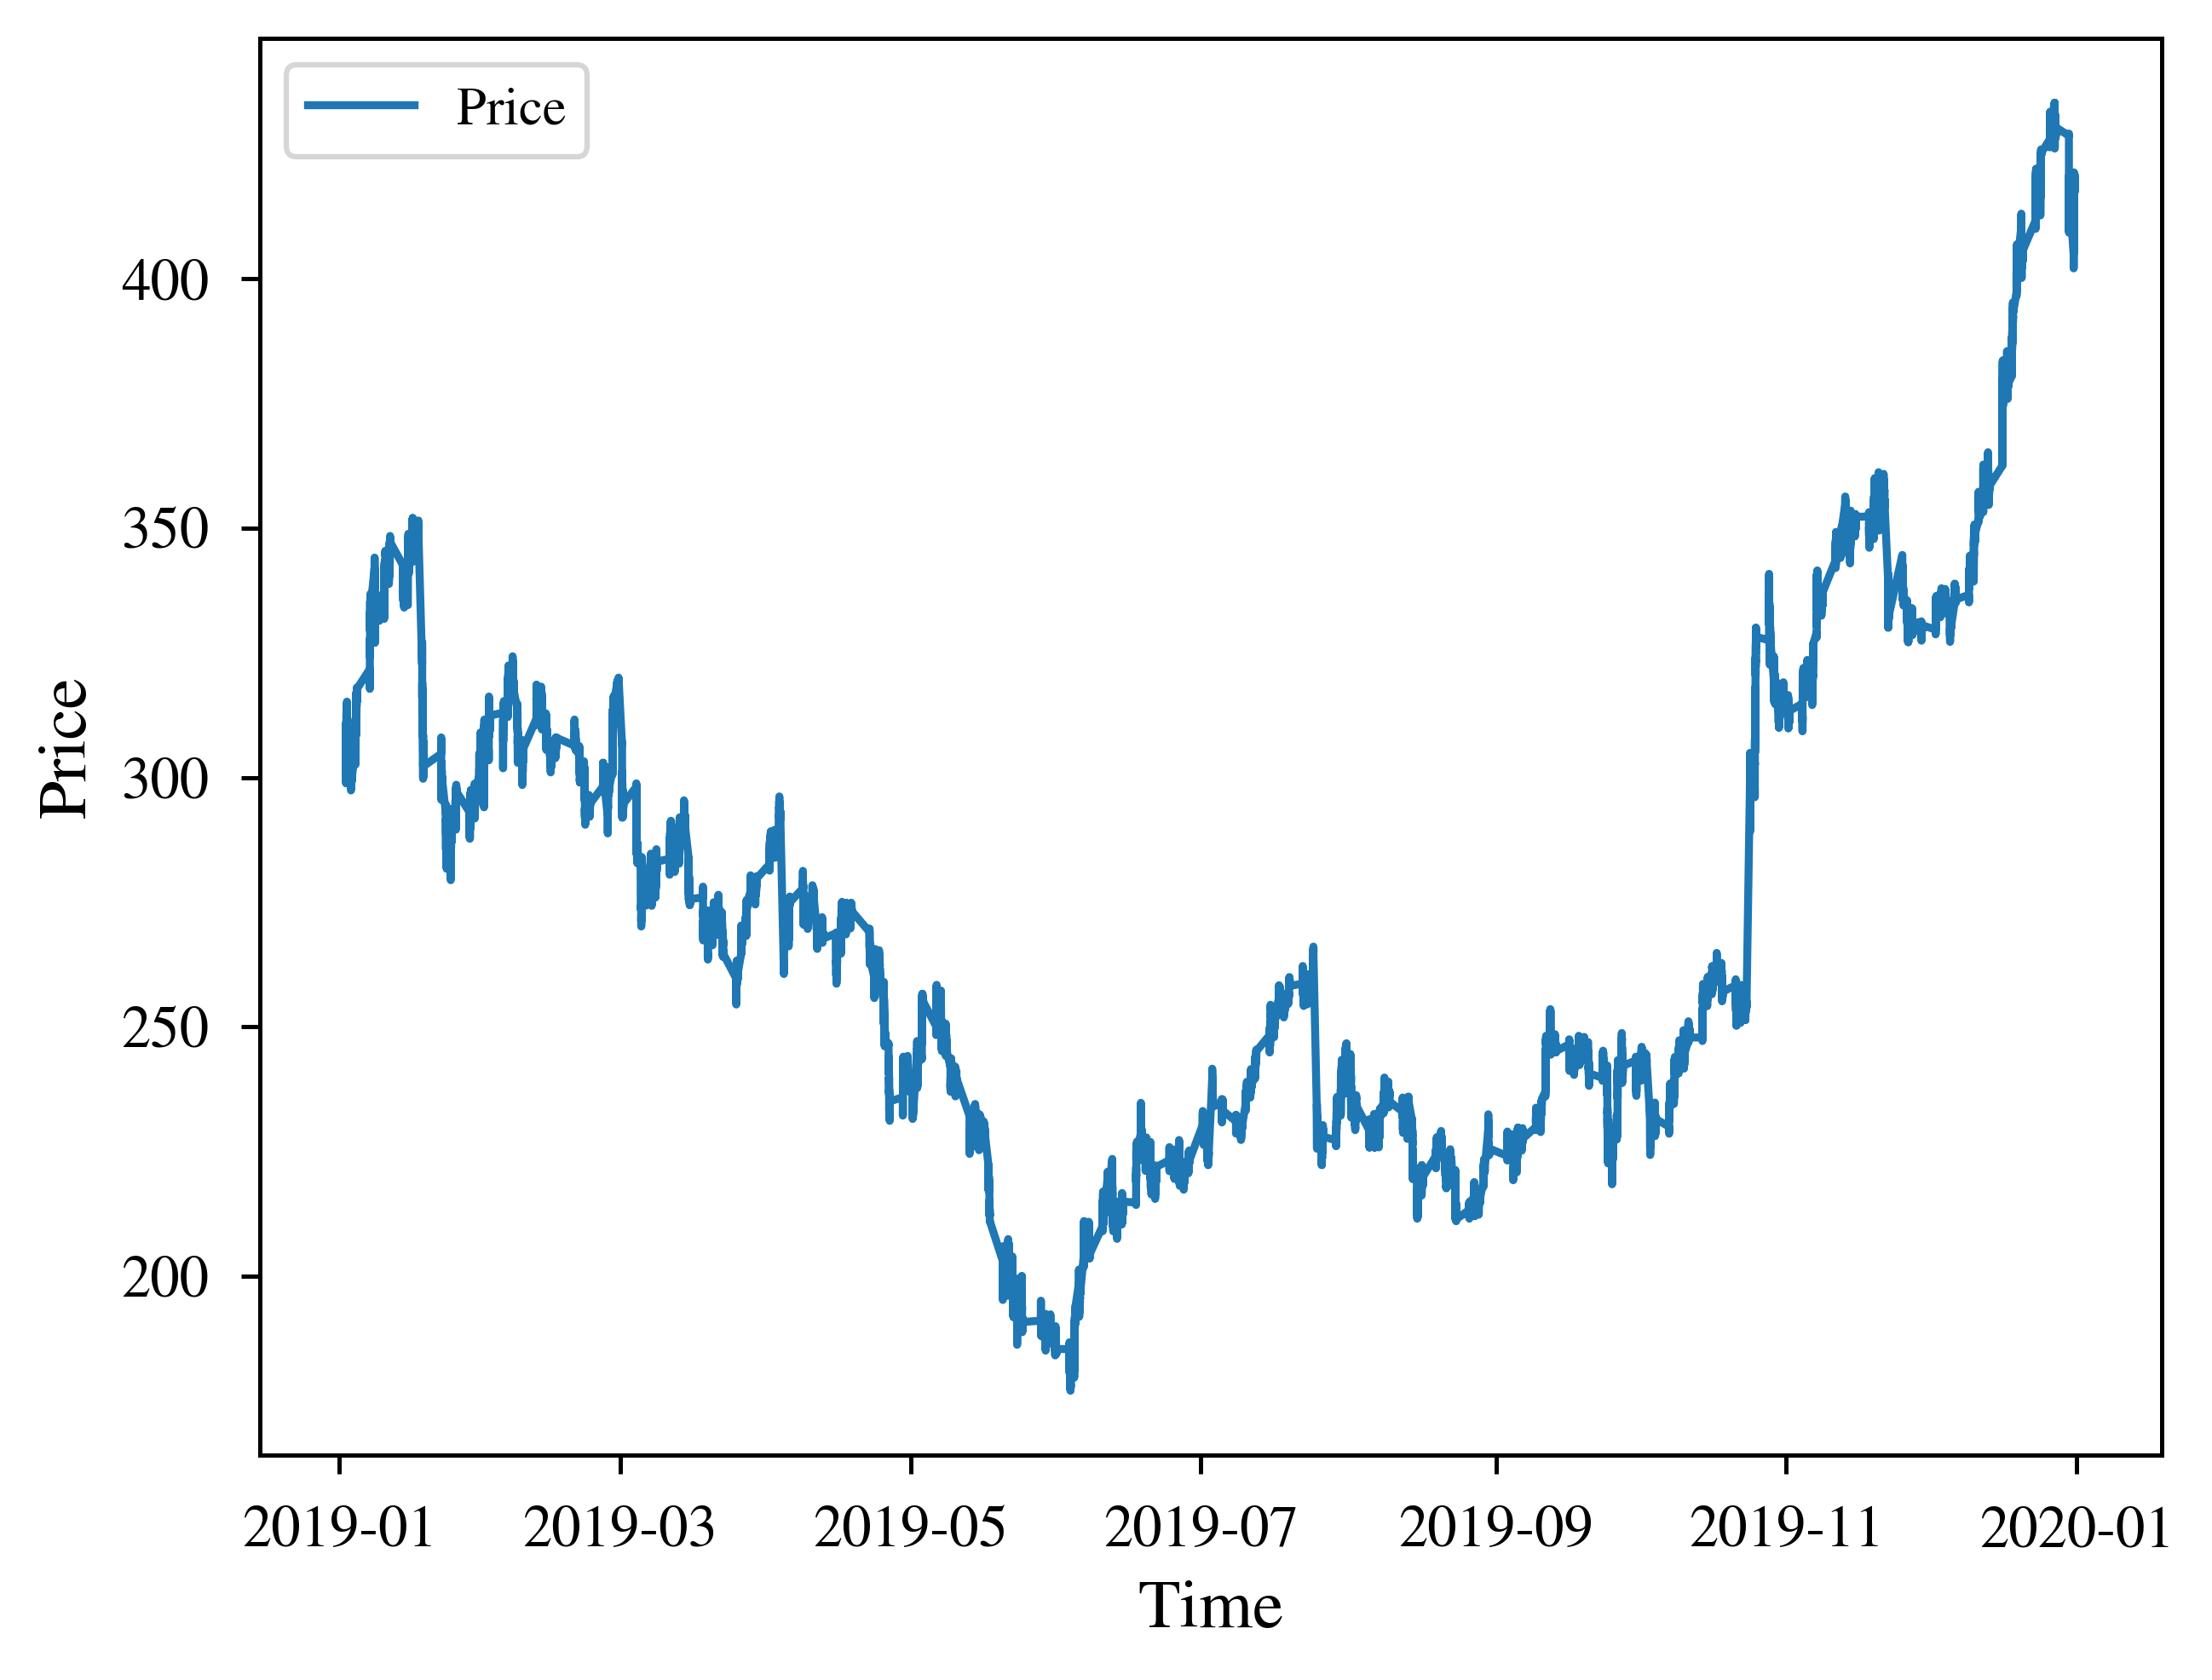

In [5]:
# Plot Raw Prices
plt.plot(tsla_l2_lob['Timestamp'], tsla_l2_lob['Price'], label='Price')
plt.legend (loc='best', fontsize=10)
plt.ylabel('Price')
plt.xlabel('Time')

### 1.2. Get Market Orders (MO)
For trades,

* Whenever a market order matches to several different limit orders, the LOBSTER data lists each separate matching order as a new line in the message and orderbook files, but with the same time-stamp.

* Whenever this happens, we batch these events together and sum the individual executed volumes to recover the original order. The sigmoid function fails to collpase otherwise.

In [6]:
# Filter events at best quotes and select
# trades (Marker Order Executions)
daily_trades = get_trades(tsla_l2_lob, price_level=1, agg_ts_events=True)
daily_trades

2026-06-01 10:25:30,321 get_data DEBUG: Starting get_trades for level 1
2026-06-01 10:25:44,131 get_data INFO: `get_trades`: processed 4375027 rows


,LOB Seq ID,Trade Seq ID,Date,Timestamp,Event,Order_ID,Price,Mid Price,Micro Price,Spread,Size,Signed Volume,Trade Direction,Price Change Indicator,Ask_Price_1,Ask_Size_1,Bid_Price_1,Bid_Size_1
0,10,0,2019-01-02,2019-01-02 09:30:00.548210475,4,11503832,306.51,306.515,306.070791,0.91,3,3,1,False,306.97,250,306.06,3
1,23,1,2019-01-02,2019-01-02 09:30:00.594026954,4,11480608,306.97,306.530,306.087379,0.94,250,250,1,True,307.00,100,306.06,3
2,63,2,2019-01-02,2019-01-02 09:30:00.801002624,4,9905484,306.67,306.365,306.063727,0.61,12,12,1,True,306.67,488,306.06,3
3,75,3,2019-01-02,2019-01-02 09:30:00.803690081,4,9905484,306.67,306.530,306.061191,0.94,488,488,1,True,307.00,2365,306.06,3
4,83,4,2019-01-02,2019-01-02 09:30:00.832255334,4,11730308,306.67,306.530,306.061191,0.94,4,4,1,False,307.00,2365,306.06,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4375022,38721884,6284694,2019-12-31,2019-12-31 15:59:58.372344377,4,284229068,418.22,418.250,418.183196,0.16,17,-17,-1,True,418.33,2225,418.17,200
4375023,38721887,6284695,2019-12-31,2019-12-31 15:59:59.237033621,4,283544692,418.33,418.250,418.184421,0.16,206,206,1,False,418.33,2019,418.17,200
4375024,38721893,6284696,2019-12-31,2019-12-31 15:59:59.282444251,4,283544692,418.33,418.250,418.184960,0.16,80,80,1,False,418.33,1939,418.17,200
4375025,38721903,6284697,2019-12-31,2019-12-31 15:59:59.349517271,4,284191296,418.17,418.250,418.178958,0.16,85,-85,-1,False,418.33,1939,418.17,115


Text(0.5, 0, 'Time')

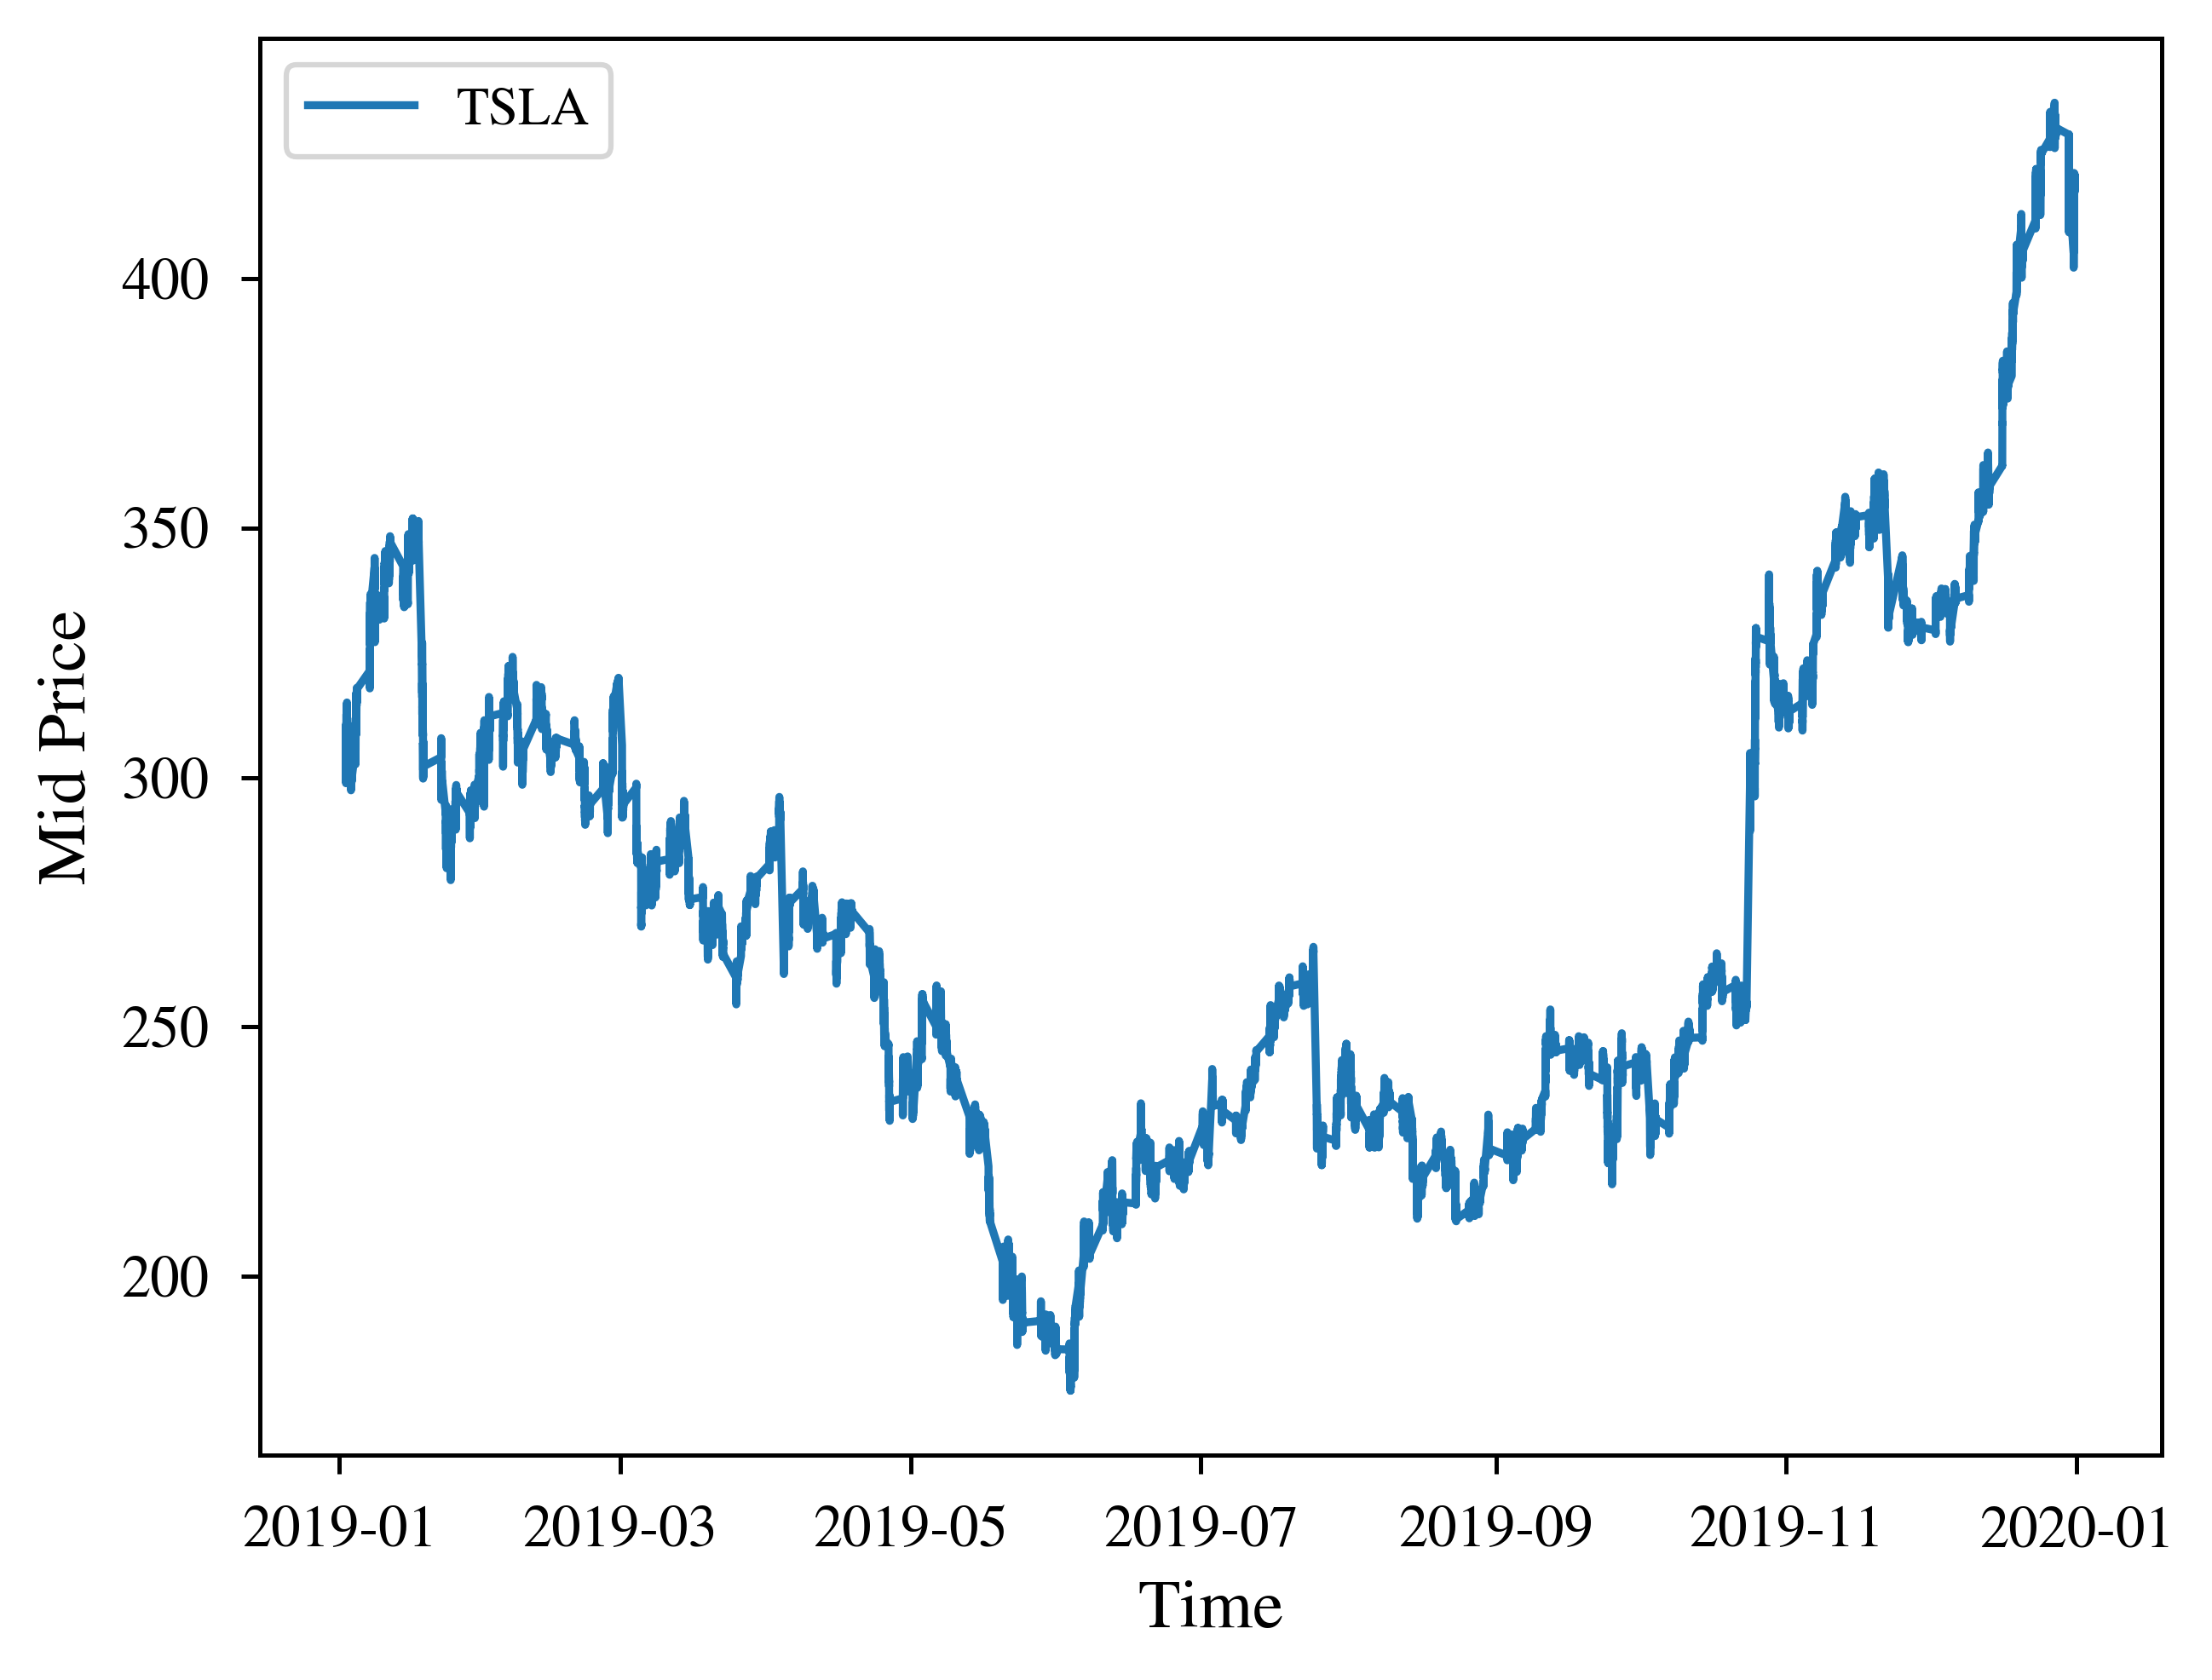

In [7]:
# Plot Level_1 Mid Prices
plt.plot(daily_trades['Timestamp'], daily_trades['Mid Price'], label='TSLA')
plt.legend (loc='best', fontsize=10)
plt.ylabel('Mid Price')
plt.xlabel('Time')

## 2. Conditional Aggregate Impact
When we calculate daily traded volumes, daily count, and average lag-1 unconditional impact,



* We consider all events for each day separately, such that no information from the previous days “spilled over”.

### 2.1. Normalisation Constant
Compute lag-1 average impact R(1).

In [8]:
# Daily R1
R1 = r1_mean_impact(daily_trades, spread_col='Spread')
R1

0.14294788809303333

### 2.2. Aggregate Volume Impact
The aggregate-volume impact is the price change (returns) over the interval $[t, t+T)$, conditioned to a certain volume imbalance:

$$
R(\Delta V, T) \colon= \langle m_{t+T} - m_t\vert \Delta V \rangle. \qquad
$$

where

* $\Delta V$ is the Volume Imbalance $ \Delta V = \sum \varepsilon_{t} v_n$,
* $\varepsilon_{t}$ denotes the sign of the nth order, and $v_t$ its volume,
* and $\langle \cdot \rangle$ denotes the empirical average over all time intervals containing $T$ successive orders, placed on the same day.

In [9]:
AggMap = {
    # Downsample aggregation map.
    "LOB Seq ID": "last",
    "Trade Seq ID": "last",
    "Date": "last",
    "Timestamp": "last",
    "Event": "last",
    "Order_ID": "last",
    "Price": "last",
    "Mid Price": "last",
    "Micro Price": "last",
    "Spread": "last",
    "Trade Direction": "last",
    "Price Change Indicator": "any",
    "Ask_Price_1": "last",
    "Ask_Size_1": "last",
    "Bid_Price_1": "last",
    "Bid_Size_1": "last",


    "Size": "sum",
    "Sign Imbalance": "sum",
    "Volume Imbalance": "sum",
    "Aggregate Returns": "sum",
    }

# Orderbook Const.
event_index = "LOB Seq ID"
direction_col = "Trade Direction"
signed_volume_col = "Signed Volume"
imbalance_col = "Volume Imbalance"
binning_frequencies = [100, 150, 200, 250]

# Returns Const.
periods = 1
returns_col = "Returns"
price_col = "Mid Price"
agg_returns_col = "Aggregate Returns"
returns_type = ReturnsType.ABSOLUTE
returns_direction = ReturnsDirection.Forward

states: list[pd.DataFrame] = []

for _, day_data in daily_trades.groupby("Date", sort=True):
    # 1-period ahead forward-looking returns
    day_data[returns_col] = returns(prices=day_data[price_col], periods=periods, returns_type=returns_type, direction=returns_direction)

    # Lag-1 unconditional price impact
    day_data = r1_impact(day_data, returns_col=returns_col, direction_col=direction_col)

    for bin_size in binning_frequencies:
        binned_data = get_impact_data(
            day_data,
            bin_size=bin_size,
            agg_map=AggMap,
            event_index=event_index,
            returns_col=returns_col,
            direction_col=direction_col,
            signed_volume_col=signed_volume_col,
        )

        normalized = agg_volume_impact(r1=R1, intraday_df=binned_data, imbalance_col=imbalance_col, agg_returns_col=agg_returns_col)

        states.append(normalized)

agg_impact_df = pd.concat(states)
agg_impact_df

,LOB Seq ID,Trade Seq ID,Date,Timestamp,Bin Size,Units,Normalised Volume Imbalance,Normalised Aggregate Returns
0,97,11,2019-01-02,2019-01-02 09:30:01.069567135,100,Events,2.770506,-1.268607
1,198,41,2019-01-02,2019-01-02 09:30:01.590091436,100,Events,-2.213660,-1.023762
2,297,72,2019-01-02,2019-01-02 09:30:01.953664829,100,Events,-11.683966,-5.710785
3,391,85,2019-01-02,2019-01-02 09:30:02.043675177,100,Events,-0.715665,-1.023762
4,463,88,2019-01-02,2019-01-02 09:30:02.240752547,100,Events,-0.211758,-0.639007
...,...,...,...,...,...,...,...,...
475,38720995,6284589,2019-12-31,2019-12-31 15:59:36.138747898,250,Events,-0.680857,-0.330832
476,38721245,6284613,2019-12-31,2019-12-31 15:59:42.504687656,250,Events,-0.789175,1.173213
477,38721448,6284649,2019-12-31,2019-12-31 15:59:48.216303012,250,Events,-0.687949,-1.310209
478,38721738,6284674,2019-12-31,2019-12-31 15:59:53.974027249,250,Events,-0.397166,-0.995409


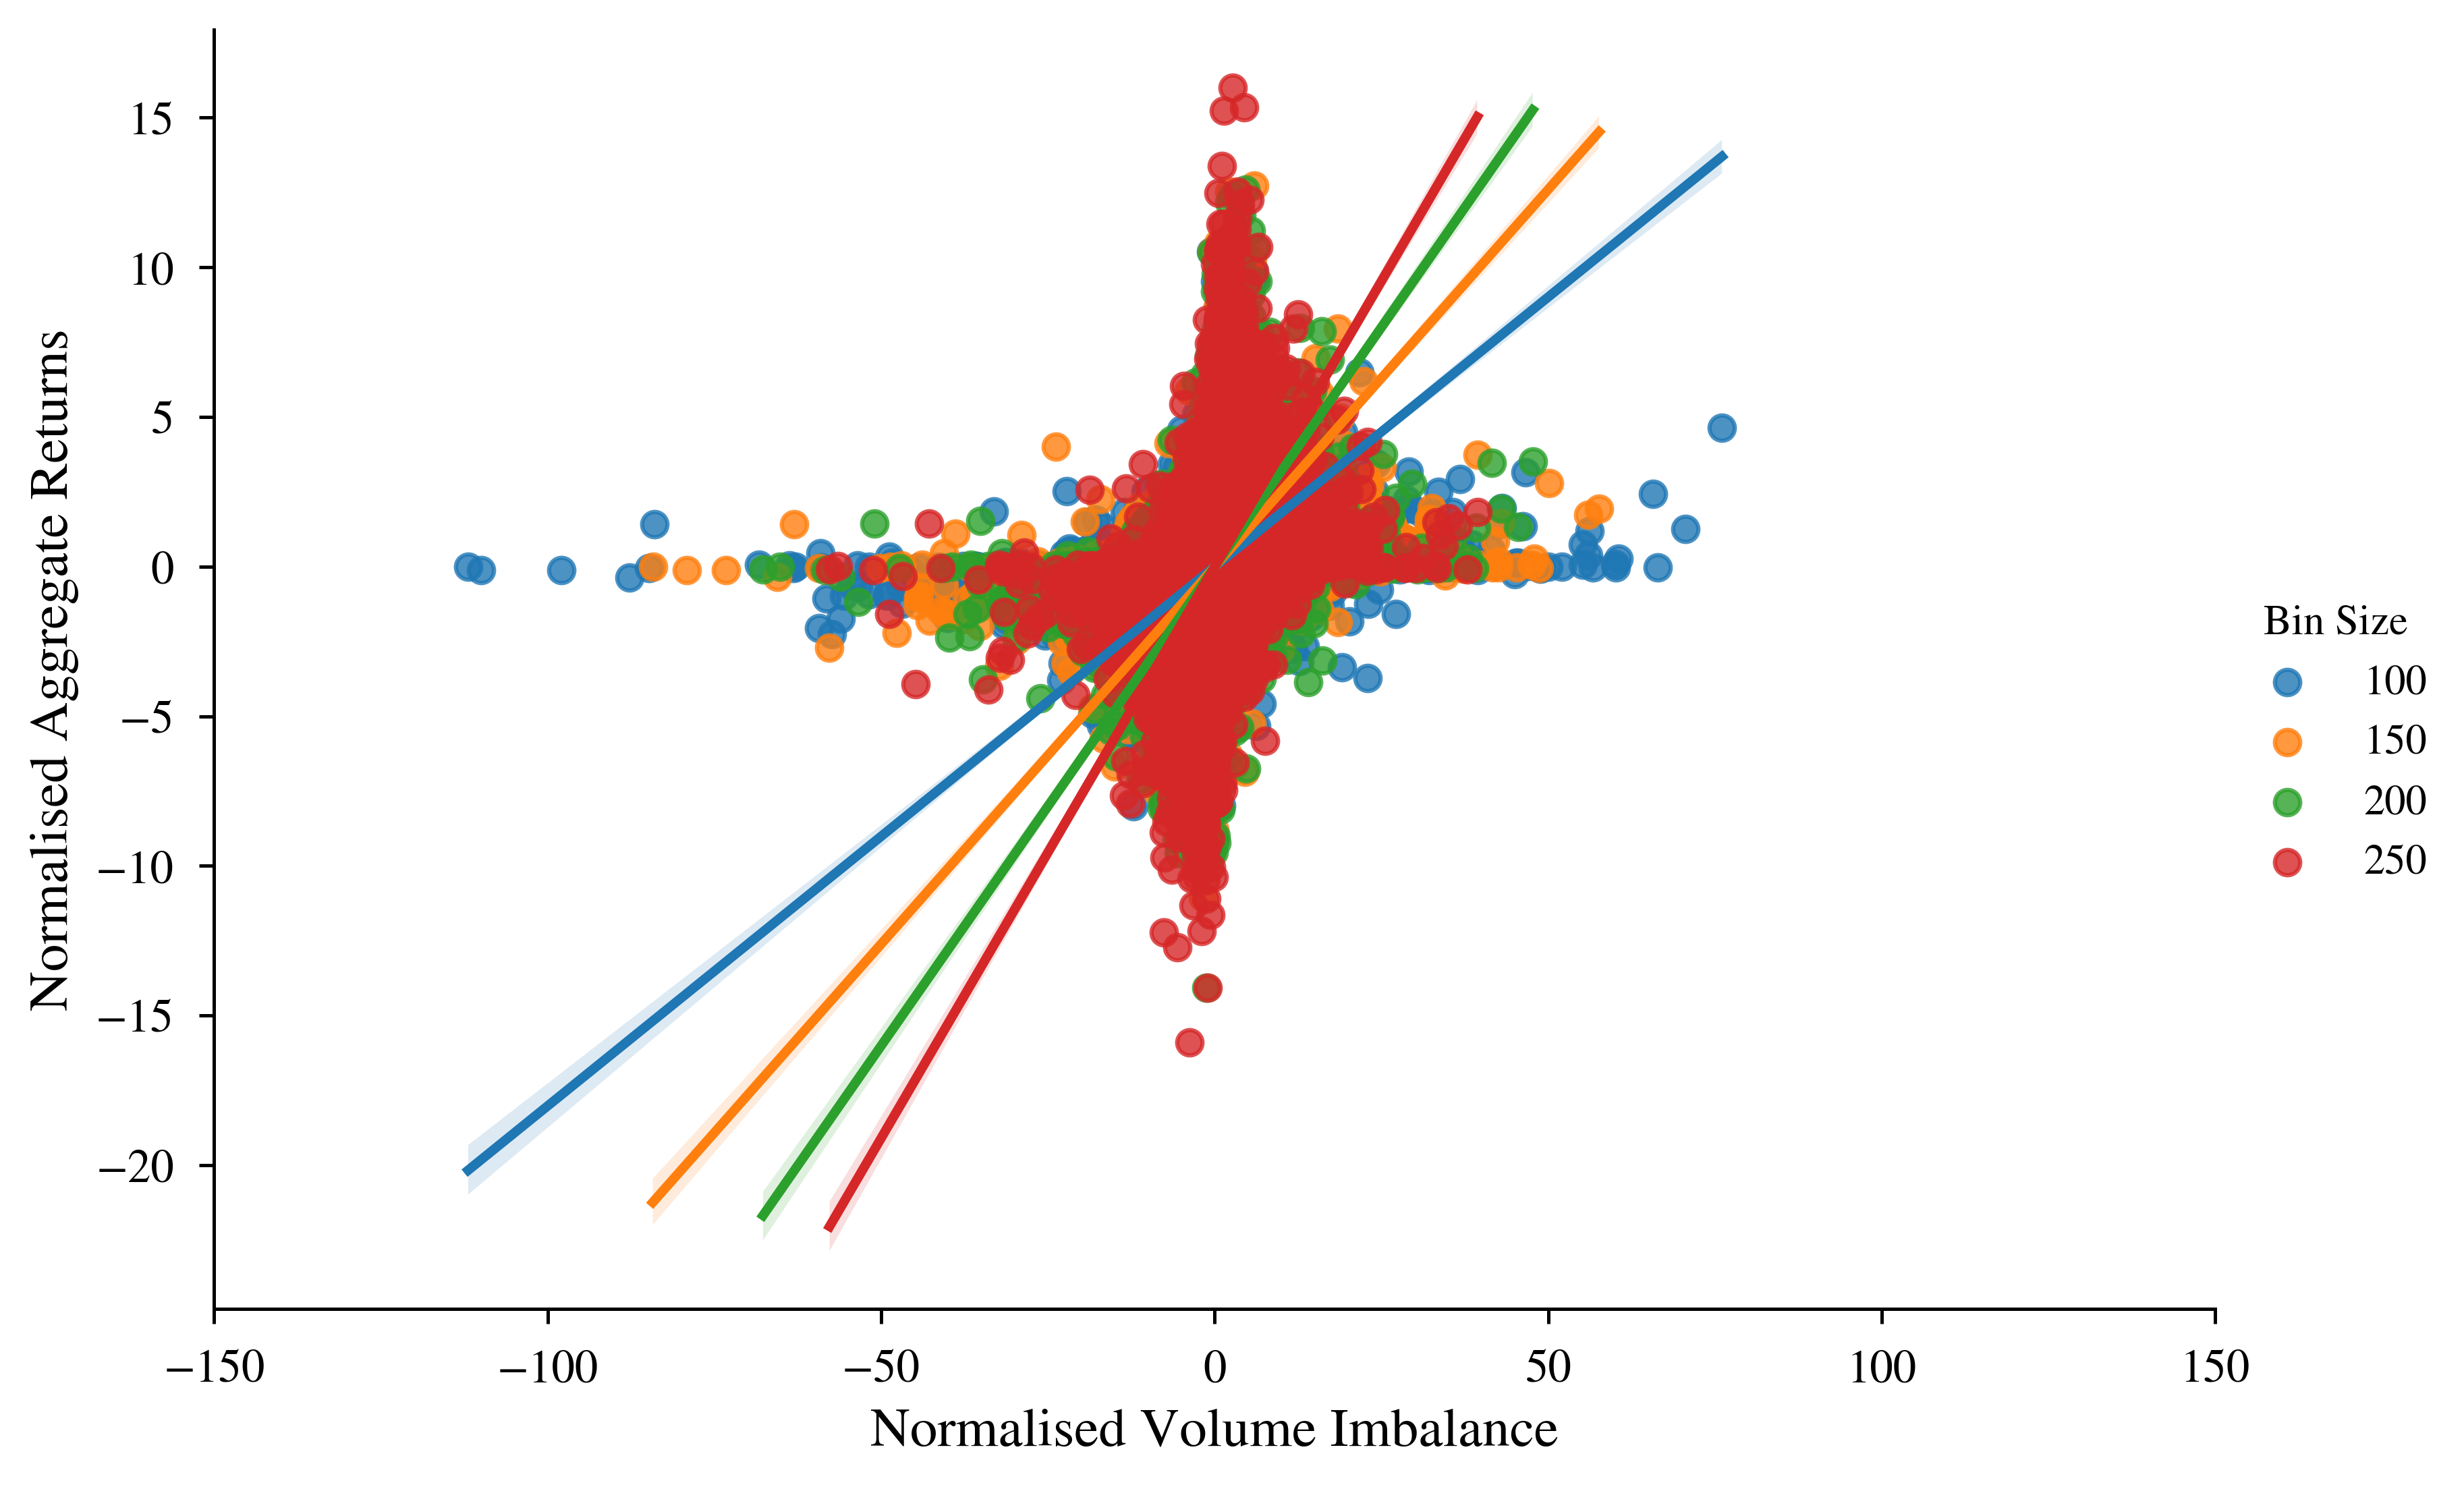

In [10]:
sns.lmplot(x=f'Normalised {imbalance_col}', y=f'Normalised {agg_returns_col}', hue='Bin Size', data=agg_impact_df, aspect=1.5)
plt.xlim(-150, 150)
plt.show()

### 2.3. Signal
Too much noise, requires binning to seperate the signal from the noise.

In [11]:
q_bins = []

for bin_size, df_bin in agg_impact_df.groupby("Bin Size", sort=True):
    resampled_data = quantile_bin_data(
        df_bin,
        x_col=f'Normalised {imbalance_col}',
        y_col=f'Normalised {agg_returns_col}',
        q=31,
        duplicates="drop",
    ).copy()

    resampled_data["Bin Size"] = bin_size
    q_bins.append(resampled_data)

binned_impact_df = pd.concat(q_bins).sort_index()

Text(0.5, 0, 'Volume Imbalance')

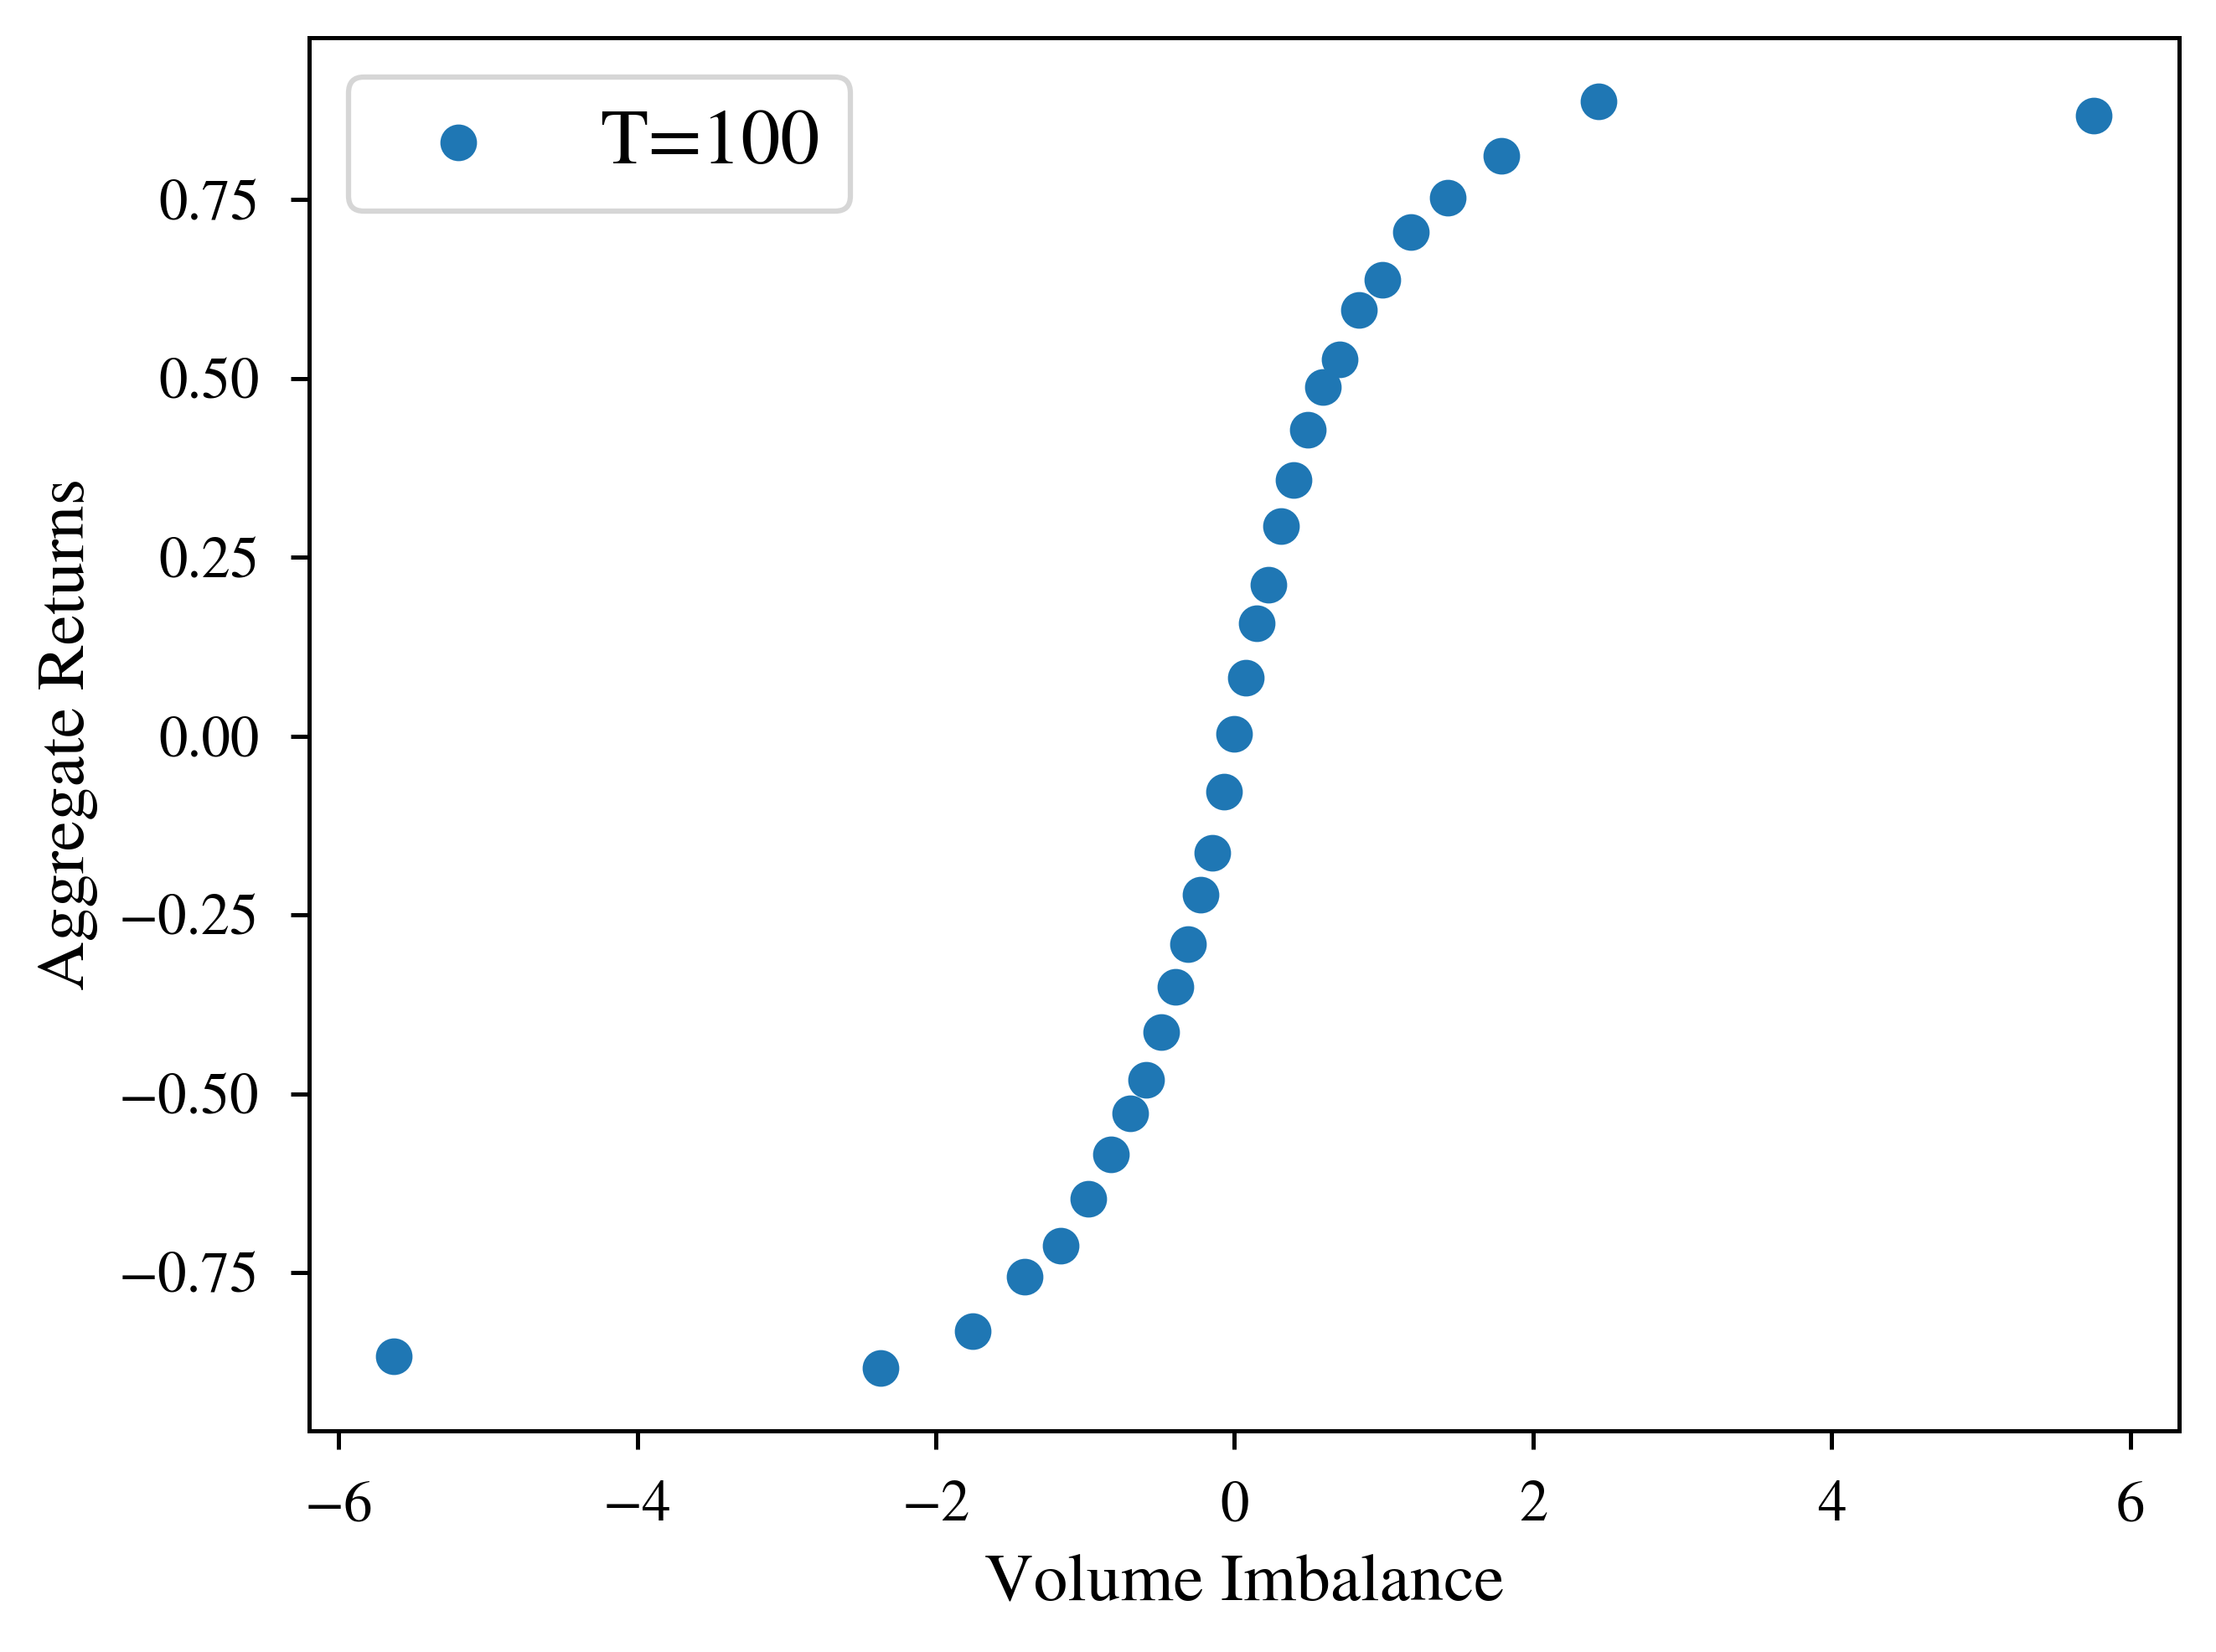

In [12]:
# Get bin_size = 100
bin_10 = binned_impact_df[binned_impact_df['Bin Size'] == 100]
plt.scatter(bin_10[f'Normalised {imbalance_col}'], bin_10[f'Normalised {agg_returns_col}'], label='T=100')
plt.legend (loc='best', fontsize=15)
plt.ylabel(r'Aggregate Returns')
plt.xlabel(r'Volume Imbalance')


### 2.4. Correlation

In [13]:
bin_10[[f'Normalised {imbalance_col}', f'Normalised {agg_returns_col}']].corr(method='spearman')

,Normalised Volume Imbalance,Normalised Aggregate Returns
Normalised Volume Imbalance,1.000000,0.999194
Normalised Aggregate Returns,0.999194,1.000000


## 3. Finite Size Scaling
We perform the FSS Analysis by fitting the Scaling Law and extracting critical exponents.

In [ ]:
from market_impact.fss import renormalise
from market_impact.util.fit_utils import fit_scaling_law
from market_impact.scaling_functions import scaling_function
from market_impact.util.plot_utils import plot_scaling_function

In [14]:
# Extract data for susceptibility
agg_impact_df.rename(columns={'Bin Size': 'T'}, inplace=True)

t_values = agg_impact_df['T'].values
r_values = agg_impact_df[f'Normalised {agg_returns_col}'].values
imbalance_values = agg_impact_df[f'Normalised {imbalance_col}'].values

# Fit data for all Bins
scaling_law = fit_scaling_law(t_values, imbalance_values, r_values)

In [15]:
params = scaling_law.params
chi, kappa, alpha, beta, CONST = params
print(f'chi: {chi}')
print(f'kappa: {kappa}')
print(f'alpha: {alpha}')
print(f'beta: {beta}')

# If x and y properly normalized,
# Const should be 1
print(f'Const: {CONST}')

chi: 0.57324698736252
kappa: 0.13655435123952442
alpha: 1.2403601472007422
beta: 1.480493498086669
Const: 0.1302174169548059


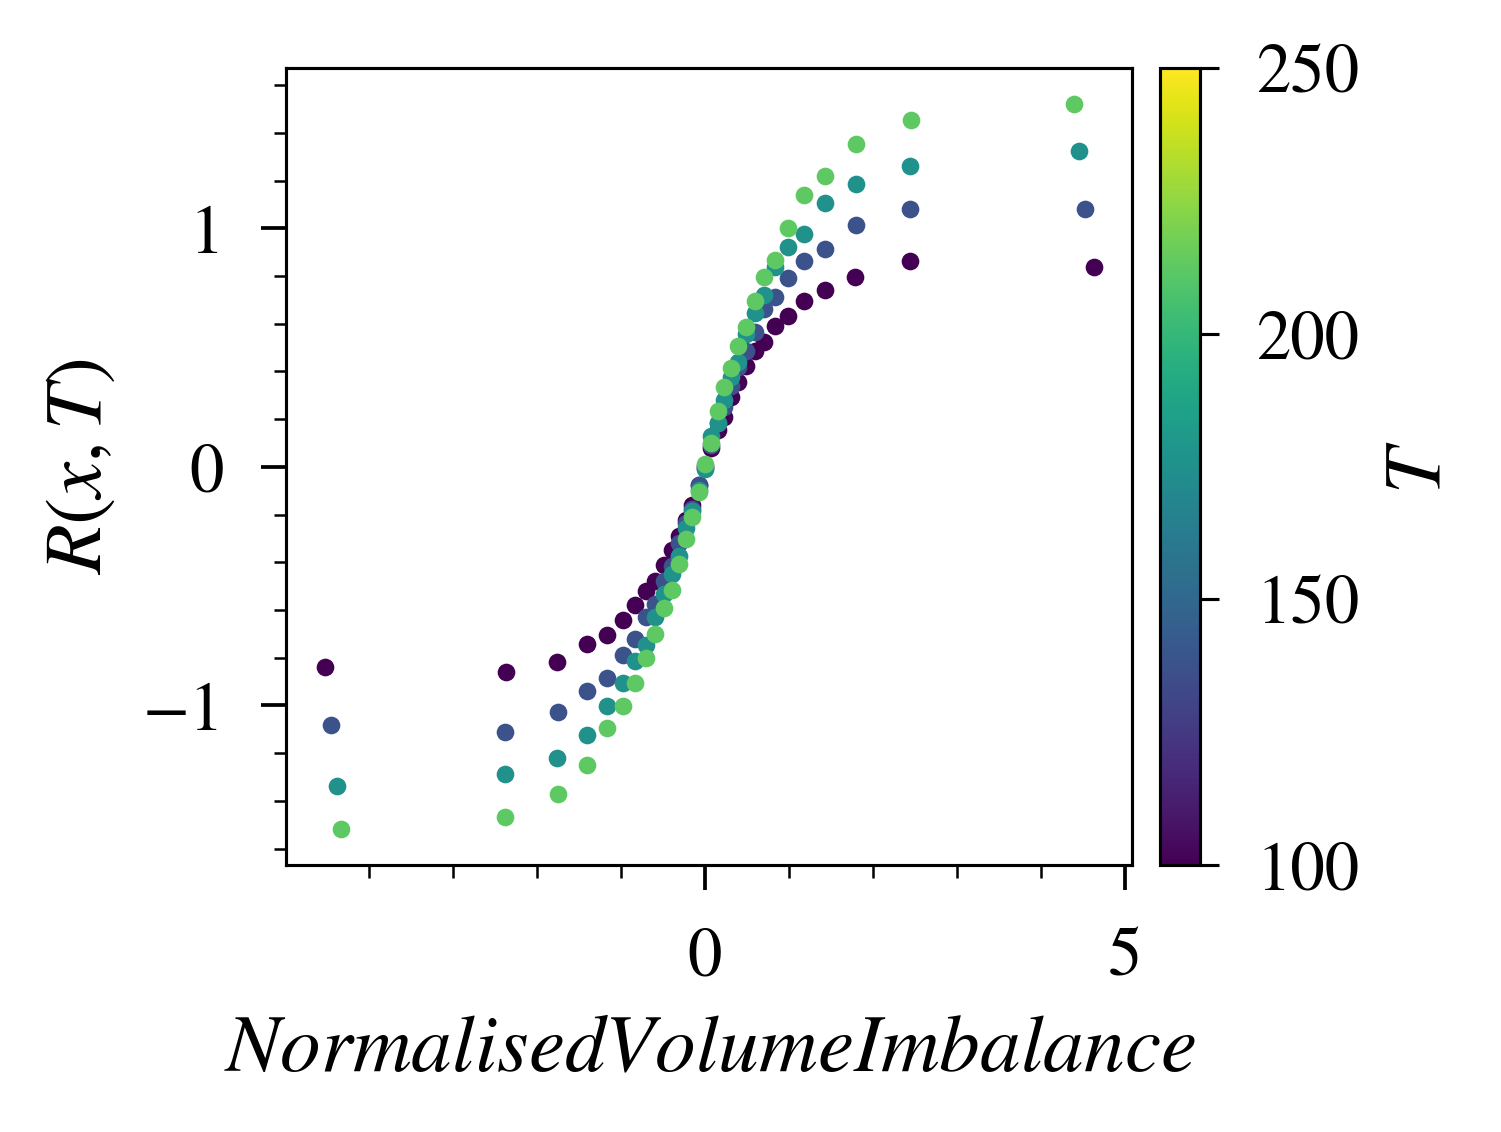

In [16]:
plot_scaling_function(
    agg_impact_df,
    scaling_params=params,
    binning_frequencies=binning_frequencies,
    imbalance_column=f'Normalised {imbalance_col}',
    response_column=f'Normalised {agg_returns_col}',
)

### 4.1. Renomalization
Transform original data using found critical exponents chi 𝛘 and kapp ϰ

In [17]:
# Transform original data using found critical exponents chi 𝛘 and kapp ϰ
rescaled_data = renormalise(agg_impact_df, rescaling_params=params, returns_column=f'Normalised {agg_returns_col}', imbalance_column=f'Normalised {imbalance_col}')

rescaled_data

,LOB Seq ID,Trade Seq ID,Date,Timestamp,T,Units,Normalised Volume Imbalance,Normalised Aggregate Returns
0,97,11,2019-01-02,2019-01-02 09:30:01.069567135,100,Events,1.477238,-0.090538
1,198,41,2019-01-02,2019-01-02 09:30:01.590091436,100,Events,-1.180326,-0.073064
2,297,72,2019-01-02,2019-01-02 09:30:01.953664829,100,Events,-6.229907,-0.407570
3,391,85,2019-01-02,2019-01-02 09:30:02.043675177,100,Events,-0.381594,-0.073064
4,463,88,2019-01-02,2019-01-02 09:30:02.240752547,100,Events,-0.112910,-0.045605
...,...,...,...,...,...,...,...,...
475,38720995,6284589,2019-12-31,2019-12-31 15:59:36.138747898,250,Events,-0.320337,-0.013964
476,38721245,6284613,2019-12-31,2019-12-31 15:59:42.504687656,250,Events,-0.371299,0.049518
477,38721448,6284649,2019-12-31,2019-12-31 15:59:48.216303012,250,Events,-0.323673,-0.055300
478,38721738,6284674,2019-12-31,2019-12-31 15:59:53.974027249,250,Events,-0.186863,-0.042014


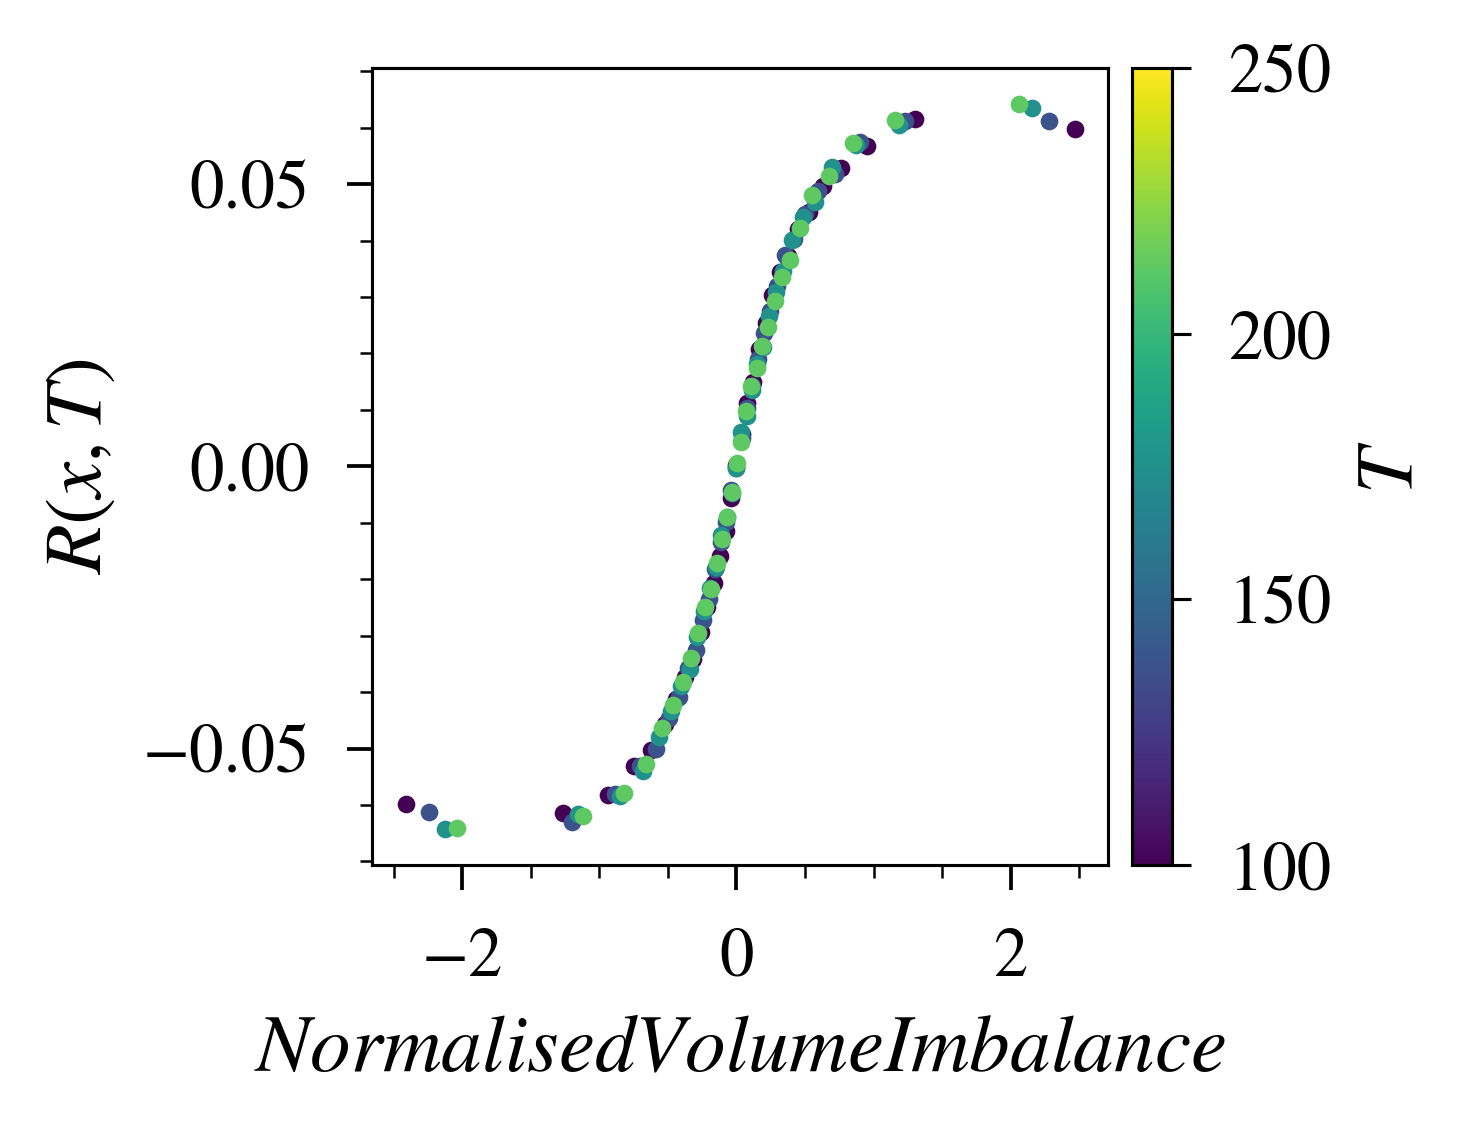

In [18]:
# Plot rescaled data
plot_scaling_function(
    rescaled_data,
    scaling_params=params,
    binning_frequencies=binning_frequencies,
    imbalance_column=f'Normalised {imbalance_col}',
    response_column=f'Normalised {agg_returns_col}',
)